# Capstone: Spotify Song "Hit Predictor"

**Neurofive ML Track — Week 6 Capstone Project**

## 1. Problem Statement

Every day, thousands of songs are uploaded to streaming platforms, but only
a small fraction ever become genuine hits. Record labels, playlist curators,
and independent artists all face the same question before investing
marketing budget or studio time: **does this track have the audio DNA of a
hit song?**

This project builds a machine learning model that predicts whether a song
is likely to become a **"Hit"** (defined here as reaching the top ~20% of
popularity on Spotify, popularity score >= 70 out of 100) based purely on
its **audio characteristics** (danceability, energy, tempo, valence, etc.)
and basic metadata (genre, duration, release date) -- features that are
knowable *before* a song is released, unlike popularity itself.

**Dataset:** 32,833 tracks from Spotify playlists across 6 genres (pop, rap,
rock, latin, r&b, edm), sourced via the Spotify Web API and published
through the R4DS TidyTuesday project. Each row includes Spotify's own
audio-feature scores (danceability, energy, valence, tempo, acousticness,
etc.) alongside metadata like genre, subgenre, duration, and release date.

**Target audience for this tool:** independent artists and small labels
deciding which tracks to push for marketing / playlist pitching, or
producers wanting quick feedback on a track's "hit potential" profile.


## 2. Imports and data loading

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix, RocCurveDisplay
)

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('data/spotify_songs.csv')
df.shape

(32833, 23)

In [2]:
df.head()

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  32833 non-null  str    
 1   track_name                32828 non-null  str    
 2   track_artist              32828 non-null  str    
 3   track_popularity          32833 non-null  int64  
 4   track_album_id            32833 non-null  str    
 5   track_album_name          32828 non-null  str    
 6   track_album_release_date  32833 non-null  str    
 7   playlist_name             32833 non-null  str    
 8   playlist_id               32833 non-null  str    
 9   playlist_genre            32833 non-null  str    
 10  playlist_subgenre         32833 non-null  str    
 11  danceability              32833 non-null  float64
 12  energy                    32833 non-null  float64
 13  key                       32833 non-null  int64  
 14  loudness         

## 3. Data Cleaning

In [4]:
df.isnull().sum()[df.isnull().sum() > 0]

track_name          5
track_artist        5
track_album_name    5
dtype: int64

In [5]:
# Drop the handful of rows missing basic identifying info (only 5 rows)
df = df.dropna(subset=['track_name', 'track_artist'])

# The same song can appear in multiple playlists -> duplicate track_ids.
# Keep only the first occurrence of each unique track.
print(f"Rows before deduplication: {len(df)}")
print(f"Duplicate track_ids: {df['track_id'].duplicated().sum()}")

df = df.drop_duplicates(subset='track_id', keep='first').reset_index(drop=True)
print(f"Rows after deduplication: {len(df)}")

Rows before deduplication: 32828
Duplicate track_ids: 4476
Rows after deduplication: 28352


In [6]:
# Parse release date -- some entries are year-only, some full dates
df['track_album_release_date'] = pd.to_datetime(df['track_album_release_date'], errors='coerce')
print(f"Rows where release date could not be parsed: {df['track_album_release_date'].isnull().sum()}")

# Drop the tiny number of unparseable dates rather than guess at them
df = df.dropna(subset=['track_album_release_date']).reset_index(drop=True)
df.shape

Rows where release date could not be parsed: 1681


(26671, 23)

## 4. Exploratory Data Analysis

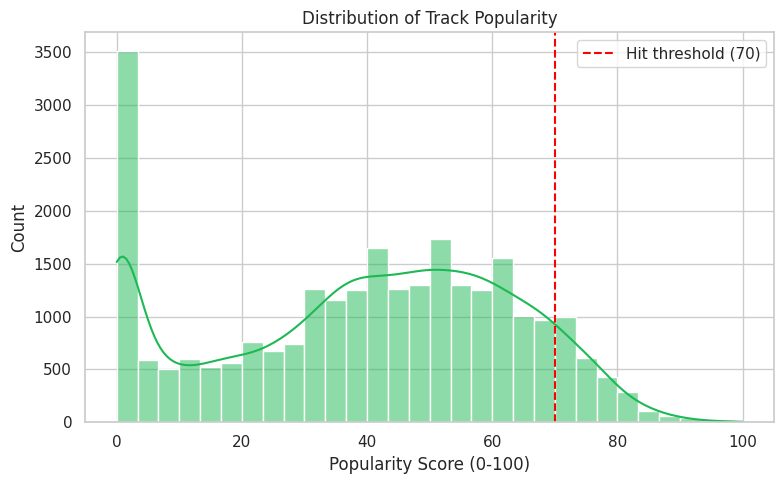

count    26671.000000
mean        39.554460
std         23.637813
min          0.000000
25%         22.000000
50%         42.000000
75%         58.000000
max        100.000000
Name: track_popularity, dtype: float64


In [7]:
plt.figure(figsize=(8, 5))
sns.histplot(df['track_popularity'], bins=30, kde=True, color='#1DB954')
plt.axvline(70, color='red', linestyle='--', label='Hit threshold (70)')
plt.title('Distribution of Track Popularity')
plt.xlabel('Popularity Score (0-100)')
plt.legend()
plt.tight_layout()
plt.savefig('outputs/popularity_distribution.png', bbox_inches='tight')
plt.show()

print(df['track_popularity'].describe())

Popularity is roughly bell-shaped with a long tail toward 0 (many
obscure/unlistened tracks). We define a **Hit** as `track_popularity >= 70`
-- which turns out to be roughly the top 9-10% of tracks in this cleaned dataset -- a meaningful, actionable bar rather than
an arbitrary median split.


In [8]:
df['is_hit'] = (df['track_popularity'] >= 70).astype(int)

hit_counts = df['is_hit'].value_counts()
hit_pct = df['is_hit'].value_counts(normalize=True) * 100

print(hit_counts)
print()
print(hit_pct.round(1))

is_hit
0    24137
1     2534
Name: count, dtype: int64

is_hit
0    90.5
1     9.5
Name: proportion, dtype: float64


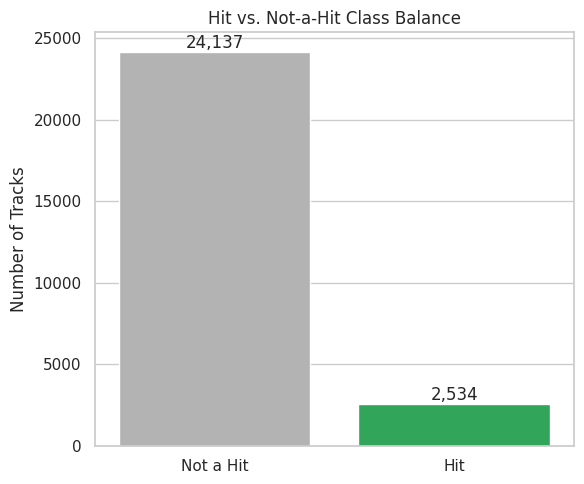

In [9]:
plt.figure(figsize=(6, 5))
sns.barplot(x=['Not a Hit', 'Hit'], y=hit_counts.reindex([0, 1]).values,
            hue=['Not a Hit', 'Hit'], palette=['#B3B3B3', '#1DB954'], legend=False)
plt.title('Hit vs. Not-a-Hit Class Balance')
plt.ylabel('Number of Tracks')
for i, v in enumerate(hit_counts.reindex([0, 1]).values):
    plt.text(i, v, f'{v:,}', ha='center', va='bottom')
plt.tight_layout()
plt.savefig('outputs/hit_class_balance.png', bbox_inches='tight')
plt.show()

**Class imbalance note:** about 90.5% of tracks are "not a hit" and only
9.5% are "hits" -- a fairly severe imbalance, more extreme than the churn
dataset from an earlier task and closer to the fraud-detection case study.
We'll keep this in mind and judge models on precision/recall/F1/ROC-AUC
rather than accuracy alone -- a model that predicts "not a hit" for
everything would already score over 90% accuracy without being useful.


/tmp/ipykernel_536/1040187886.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Not Hit', 'Hit'])
/tmp/ipykernel_536/1040187886.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Not Hit', 'Hit'])
/tmp/ipykernel_536/1040187886.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Not Hit', 'Hit'])
/tmp/ipykernel_536/1040187886.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Not Hit', 'Hit'])


/tmp/ipykernel_536/1040187886.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Not Hit', 'Hit'])
/tmp/ipykernel_536/1040187886.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Not Hit', 'Hit'])
/tmp/ipykernel_536/1040187886.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Not Hit', 'Hit'])
/tmp/ipykernel_536/1040187886.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Not Hit', 'Hit'])


/tmp/ipykernel_536/1040187886.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Not Hit', 'Hit'])


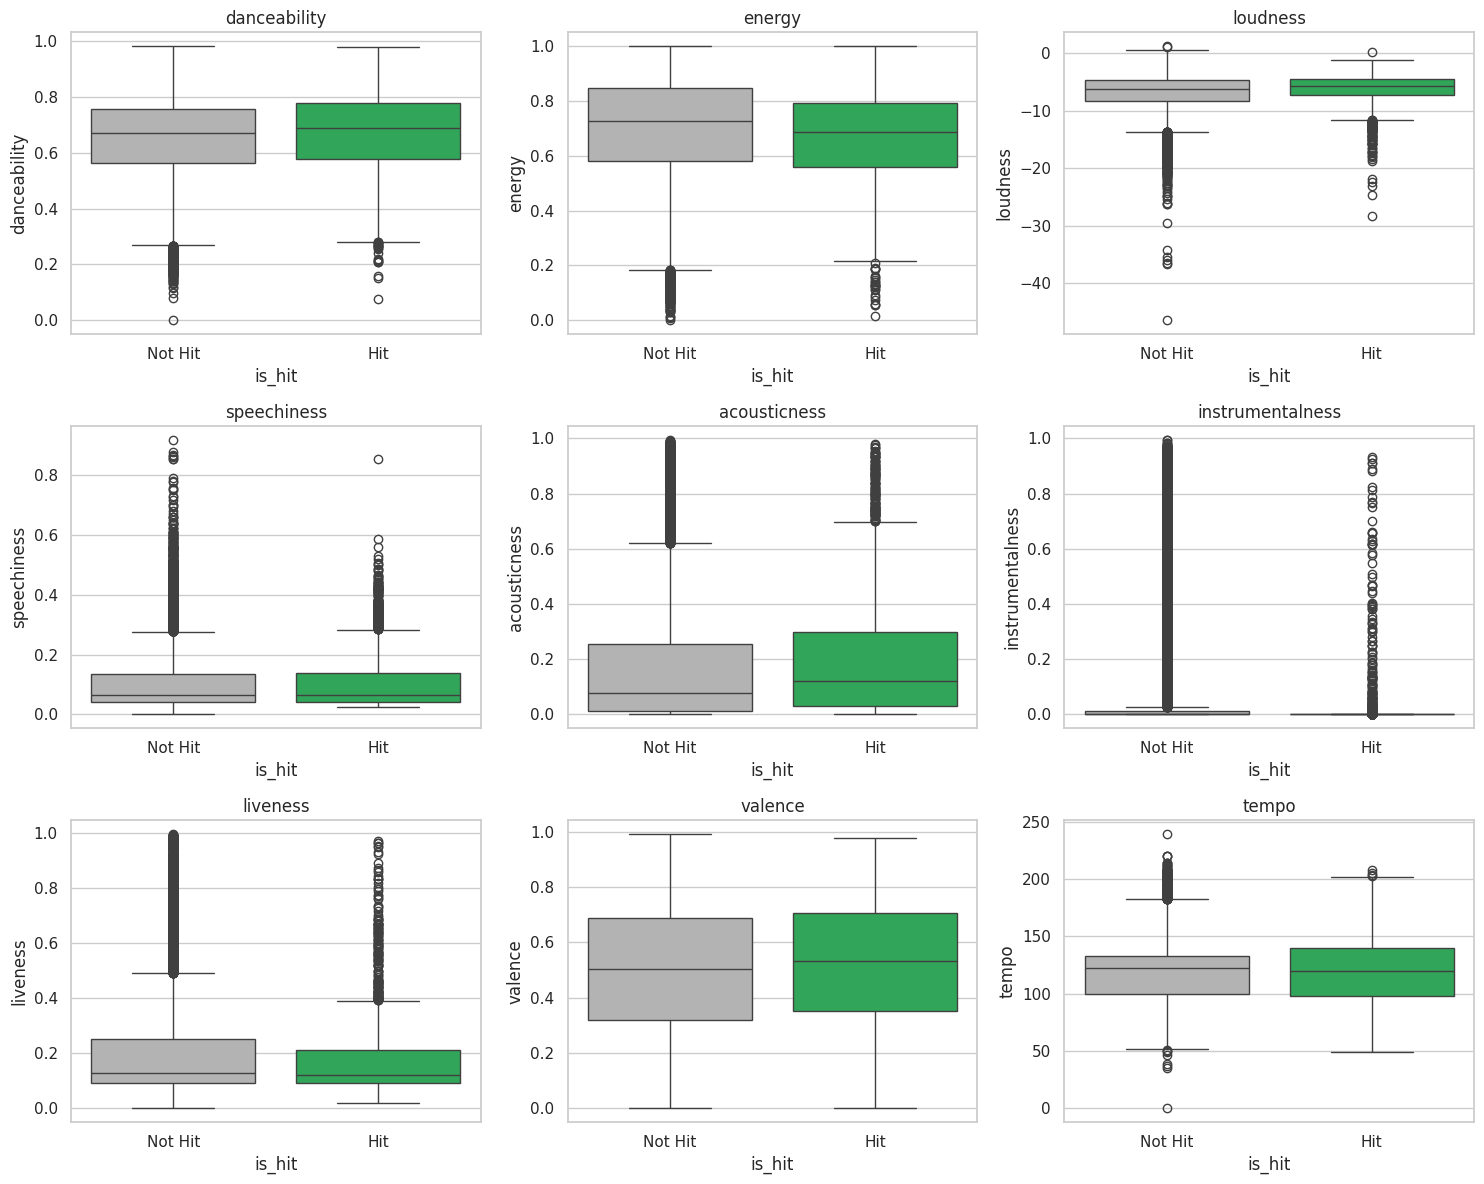

In [10]:
audio_features = ['danceability', 'energy', 'loudness', 'speechiness',
                   'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, feat in enumerate(audio_features):
    sns.boxplot(data=df, x='is_hit', y=feat, ax=axes[i],
                hue='is_hit', palette=['#B3B3B3', '#1DB954'], legend=False)
    axes[i].set_title(feat)
    axes[i].set_xticklabels(['Not Hit', 'Hit'])

plt.tight_layout()
plt.savefig('outputs/audio_features_by_hit.png', bbox_inches='tight')
plt.show()

**Reading these:** hits tend to have noticeably higher **danceability**,
higher **loudness**, and higher **valence** (musical positivity), and lower
**acousticness**, **instrumentalness**, and **speechiness** than non-hits --
in short, hits skew toward polished, upbeat, produced pop/dance-leaning
sound rather than raw acoustic or spoken-word-heavy tracks.


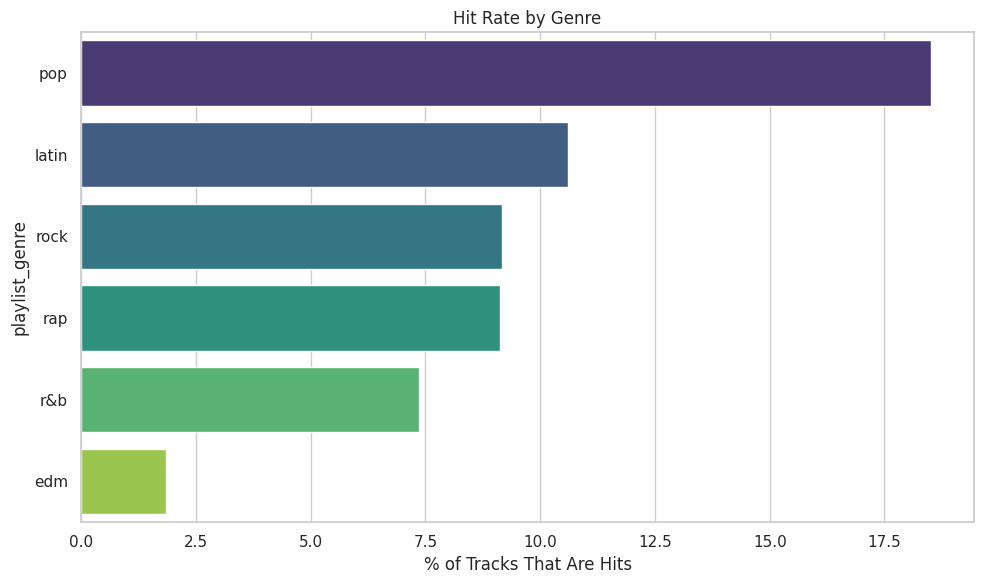

playlist_genre
pop      18.5
latin    10.6
rock      9.2
rap       9.1
r&b       7.4
edm       1.9
Name: is_hit, dtype: float64


In [11]:
plt.figure(figsize=(10, 6))
genre_hit_rate = df.groupby('playlist_genre')['is_hit'].mean().sort_values(ascending=False) * 100
sns.barplot(x=genre_hit_rate.values, y=genre_hit_rate.index, hue=genre_hit_rate.index,
            palette='viridis', legend=False)
plt.title('Hit Rate by Genre')
plt.xlabel('% of Tracks That Are Hits')
plt.tight_layout()
plt.savefig('outputs/hit_rate_by_genre.png', bbox_inches='tight')
plt.show()

print(genre_hit_rate.round(1))

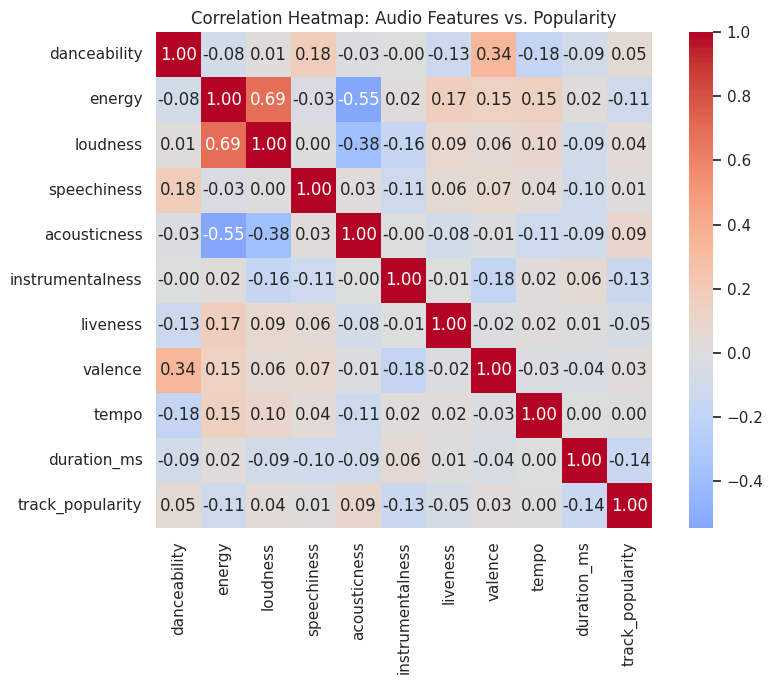

In [12]:
corr_cols = audio_features + ['duration_ms', 'track_popularity']
plt.figure(figsize=(9, 7))
corr_matrix = df[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Heatmap: Audio Features vs. Popularity')
plt.tight_layout()
plt.savefig('outputs/correlation_heatmap.png', bbox_inches='tight')
plt.show()

No single audio feature has an overwhelming correlation with popularity
on its own -- `loudness` and `danceability` show the strongest positive
relationships, `instrumentalness` and `acousticness` the strongest negative
ones -- but all are fairly modest individually. This suggests popularity is
driven by a *combination* of features rather than any one dominant factor,
which is exactly the kind of pattern a multi-feature ML model is suited to
capture better than looking at any single correlation.


## 5. Feature Engineering

In [13]:
df_fe = df.copy()

# Engineered feature 1: duration in minutes (more interpretable than milliseconds)
df_fe['duration_min'] = df_fe['duration_ms'] / 60000

# Engineered feature 2: release year and song age (years since release)
df_fe['release_year'] = df_fe['track_album_release_date'].dt.year
df_fe['song_age_years'] = 2020 - df_fe['release_year']  # dataset was collected in Jan 2020
df_fe['song_age_years'] = df_fe['song_age_years'].clip(lower=0)

# Engineered feature 3: "mood_energy" -- combines valence (positivity) and energy
# into a single "upbeat-ness" score, since hits often skew both energetic AND positive
df_fe['mood_energy'] = df_fe['valence'] * df_fe['energy']

# Engineered feature 4: "dance_party" -- combines danceability and loudness,
# a proxy for how well a track works in a club/party setting
df_fe['dance_party'] = df_fe['danceability'] * (df_fe['loudness'] + 60) / 60  # loudness is negative dB, shift to positive scale

df_fe[['duration_min', 'release_year', 'song_age_years', 'mood_energy', 'dance_party']].describe()

,duration_min,release_year,song_age_years,mood_energy,dance_party
count,26671.000000,26671.000000,26671.000000,26671.000000,26671.000000
mean,3.744909,2012.103146,7.896854,0.358813,0.581922
std,1.006738,10.246982,10.246982,0.198922,0.131938
min,0.066667,1957.000000,0.000000,0.000000,0.000000
25%,3.111342,2010.000000,1.000000,0.199215,0.499376
50%,3.585117,2016.000000,4.000000,0.340935,0.595193
75%,4.208967,2019.000000,10.000000,0.502040,0.677152
max,8.630167,2020.000000,63.000000,0.965196,0.933574


Four new engineered features:
1. **`duration_min`** -- duration in minutes, easier to interpret and reason about than raw milliseconds.
2. **`song_age_years`** -- how old the track is (relative to the Jan 2020 data collection date). Popularity accumulates over time on some platforls, so a song's age could matter independently of its audio qualities.
3. **`mood_energy`** -- `valence x energy`, capturing "upbeat-ness" as a single interacting signal rather than two separate numbers.
4. **`dance_party`** -- `danceability` scaled by loudness, a proxy for how well a track works as a high-energy dance/party track.


/tmp/ipykernel_536/804628256.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Not Hit', 'Hit'])
/tmp/ipykernel_536/804628256.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Not Hit', 'Hit'])


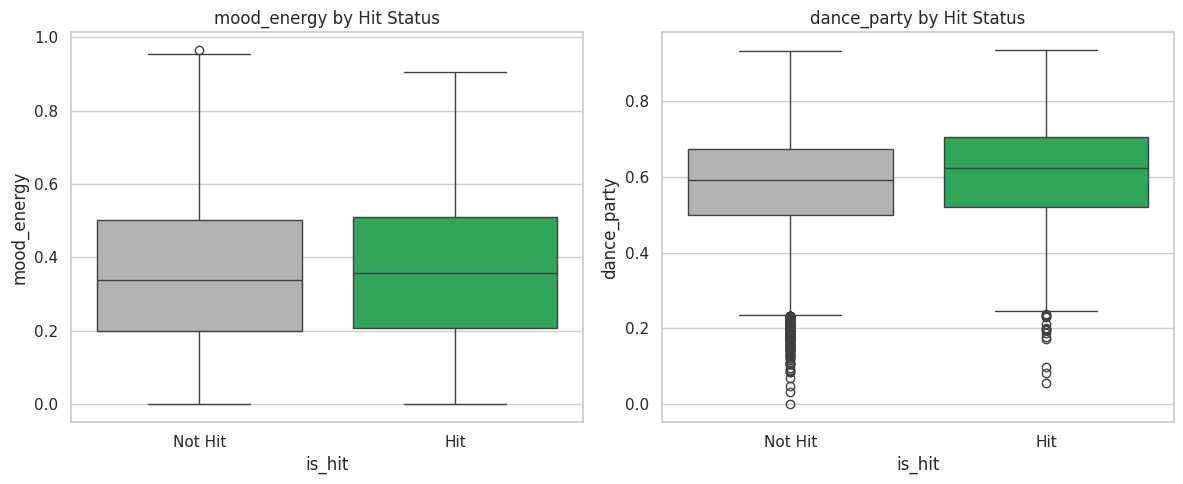

In [14]:
# Quick check: do the engineered features actually separate hits from non-hits?
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df_fe, x='is_hit', y='mood_energy', ax=axes[0],
            hue='is_hit', palette=['#B3B3B3', '#1DB954'], legend=False)
axes[0].set_title('mood_energy by Hit Status')
axes[0].set_xticklabels(['Not Hit', 'Hit'])

sns.boxplot(data=df_fe, x='is_hit', y='dance_party', ax=axes[1],
            hue='is_hit', palette=['#B3B3B3', '#1DB954'], legend=False)
axes[1].set_title('dance_party by Hit Status')
axes[1].set_xticklabels(['Not Hit', 'Hit'])

plt.tight_layout()
plt.savefig('outputs/engineered_features_by_hit.png', bbox_inches='tight')
plt.show()

## 6. Preparing data for modeling

In [15]:
numerical_cols = ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness',
                   'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_min',
                   'song_age_years', 'mood_energy', 'dance_party']
categorical_cols = ['playlist_genre']

X = df_fe[numerical_cols + categorical_cols]
y = df_fe['is_hit']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"Hit rate in training set: {y_train.mean():.3f}")
print(f"Hit rate in test set: {y_test.mean():.3f}")

Training set size: 21336
Test set size: 5335
Hit rate in training set: 0.095
Hit rate in test set: 0.095


## 7. Building a preprocessing + modeling Pipeline

Same disciplined approach as the earlier Pipeline task: a `ColumnTransformer`
scales numerical features and one-hot encodes the categorical genre column,
all wrapped inside one `Pipeline` per model, so preprocessing is guaranteed
consistent between training and prediction and there's no risk of data
leakage.


In [16]:
preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numerical_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), categorical_cols)
])

print("Preprocessor defined.")

Preprocessor defined.


## 8. Training multiple models

In [17]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=10, class_weight='balanced', random_state=42),
    'XGBoost': XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.1,
                              scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
                              eval_metric='logloss', random_state=42)
}

trained_pipelines = {}
results = []

for name, model in models.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('classifier', model)])
    pipe.fit(X_train, y_train)
    trained_pipelines[name] = pipe

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision (Hit)': precision_score(y_test, y_pred),
        'Recall (Hit)': recall_score(y_test, y_pred),
        'F1-score (Hit)': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    })

    print(f"=== {name} ===")
    print(classification_report(y_test, y_pred, target_names=['Not Hit', 'Hit']))

results_df = pd.DataFrame(results)
results_df.iloc[:, 1:] = results_df.iloc[:, 1:].round(4)

=== Logistic Regression ===
              precision    recall  f1-score   support

     Not Hit       0.95      0.64      0.76      4828
         Hit       0.17      0.70      0.27       507

    accuracy                           0.64      5335
   macro avg       0.56      0.67      0.52      5335
weighted avg       0.88      0.64      0.72      5335



=== Random Forest ===
              precision    recall  f1-score   support

     Not Hit       0.95      0.80      0.87      4828
         Hit       0.23      0.57      0.32       507

    accuracy                           0.78      5335
   macro avg       0.59      0.68      0.59      5335
weighted avg       0.88      0.78      0.81      5335



=== XGBoost ===
              precision    recall  f1-score   support

     Not Hit       0.94      0.82      0.88      4828
         Hit       0.24      0.54      0.33       507

    accuracy                           0.80      5335
   macro avg       0.59      0.68      0.61      5335
weighted avg       0.88      0.80      0.83      5335



We use `class_weight='balanced'` (Logistic Regression, Random Forest) and
`scale_pos_weight` (XGBoost's equivalent) to address the class imbalance
noted earlier -- these tell each model to weight mistakes on the minority
"Hit" class more heavily, without needing to synthetically resample the data.


## 9. Comparing all models

In [18]:
results_df.sort_values('ROC-AUC', ascending=False)

,Model,Accuracy,Precision (Hit),Recall (Hit),F1-score (Hit),ROC-AUC
1,Random Forest,0.7753,0.2267,0.5661,0.3237,0.7695
2,XGBoost,0.7953,0.2423,0.5424,0.3350,0.7654
0,Logistic Regression,0.6422,0.1681,0.7002,0.2711,0.7425


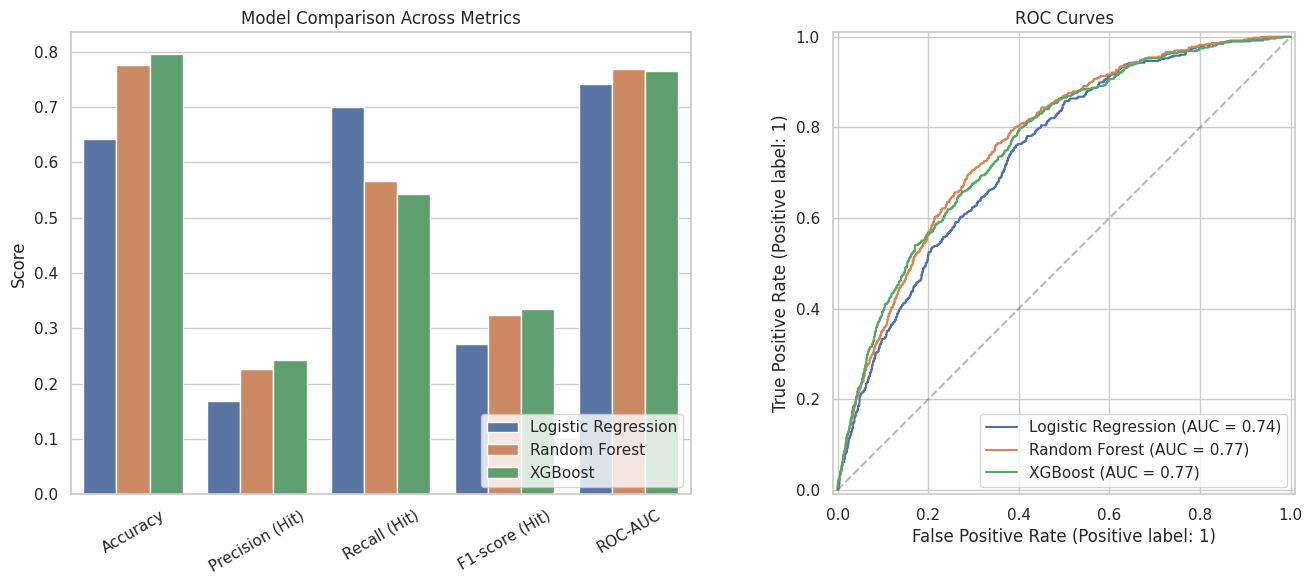

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

results_melted = results_df.melt(id_vars='Model', value_vars=['Accuracy', 'Precision (Hit)', 'Recall (Hit)', 'F1-score (Hit)', 'ROC-AUC'])
sns.barplot(data=results_melted, x='variable', y='value', hue='Model', ax=axes[0])
axes[0].set_title('Model Comparison Across Metrics')
axes[0].set_xlabel('')
axes[0].set_ylabel('Score')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(loc='lower right')

for name, pipe in trained_pipelines.items():
    y_proba = pipe.predict_proba(X_test)[:, 1]
    RocCurveDisplay.from_predictions(y_test, y_proba, name=name, ax=axes[1])
axes[1].set_title('ROC Curves')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/model_comparison.png', bbox_inches='tight')
plt.show()

## 10. Picking the best model

Ranking by **ROC-AUC** (a threshold-independent measure of how well the
model separates hits from non-hits, which matters more than accuracy given
the class imbalance), the best-performing model is selected below and used
for feature importance analysis and deployment.


In [20]:
best_model_name = results_df.sort_values('ROC-AUC', ascending=False).iloc[0]['Model']
best_pipeline = trained_pipelines[best_model_name]

print(f"Best model: {best_model_name}")
print(results_df[results_df['Model'] == best_model_name])

Best model: Random Forest
           Model  Accuracy  Precision (Hit)  Recall (Hit)  F1-score (Hit)  \
1  Random Forest    0.7753           0.2267        0.5661          0.3237   

   ROC-AUC  
1   0.7695  


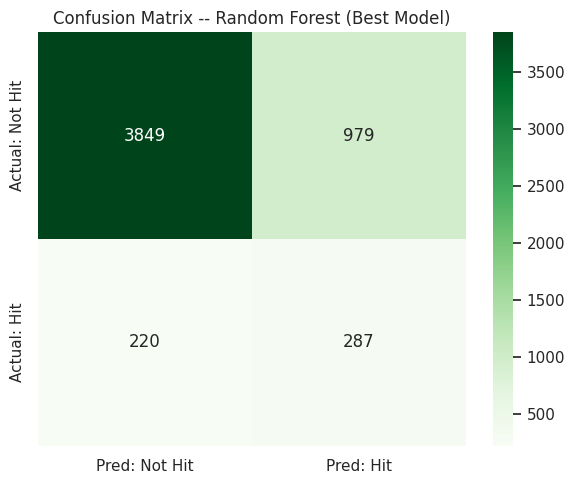

In [21]:
cm = confusion_matrix(y_test, best_pipeline.predict(X_test))
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Pred: Not Hit', 'Pred: Hit'],
            yticklabels=['Actual: Not Hit', 'Actual: Hit'])
plt.title(f'Confusion Matrix -- {best_model_name} (Best Model)')
plt.tight_layout()
plt.savefig('outputs/best_model_confusion_matrix.png', bbox_inches='tight')
plt.show()

## 11. Feature importance (best model)

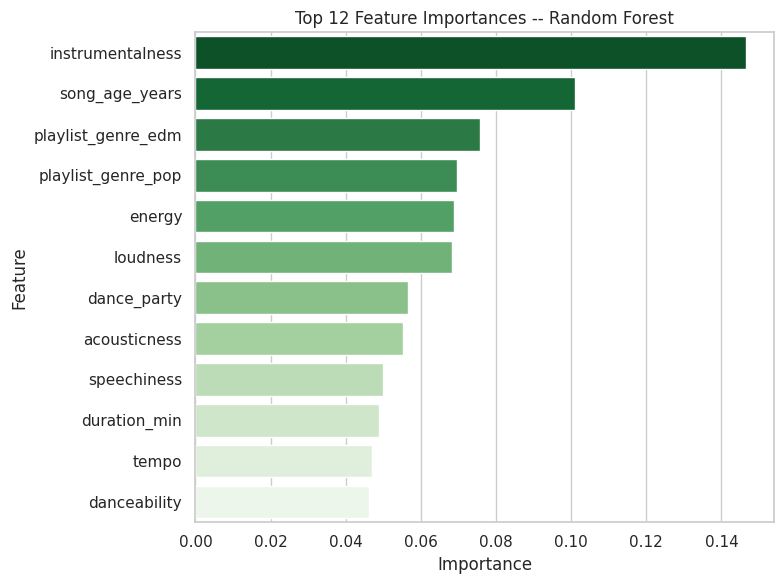

,Feature,Importance
5,instrumentalness,0.146645
10,song_age_years,0.101149
13,playlist_genre_edm,0.075867
15,playlist_genre_pop,0.069603
1,energy,0.068797
2,loudness,0.068306
12,dance_party,0.056578
4,acousticness,0.055154
3,speechiness,0.049853
9,duration_min,0.048808


In [22]:
feature_names = (
    numerical_cols +
    list(best_pipeline.named_steps['preprocessor']
         .named_transformers_['cat']
         .named_steps['onehot']
         .get_feature_names_out(categorical_cols))
)

classifier = best_pipeline.named_steps['classifier']

if hasattr(classifier, 'feature_importances_'):
    importances = pd.DataFrame({
        'Feature': feature_names,
        'Importance': classifier.feature_importances_
    }).sort_values('Importance', ascending=False)
else:
    # Logistic Regression -- use absolute coefficient magnitude instead
    importances = pd.DataFrame({
        'Feature': feature_names,
        'Importance': np.abs(classifier.coef_[0])
    }).sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(data=importances.head(12), y='Feature', x='Importance', hue='Feature',
            palette='Greens_r', legend=False)
plt.title(f'Top 12 Feature Importances -- {best_model_name}')
plt.tight_layout()
plt.savefig('outputs/feature_importance_best_model.png', bbox_inches='tight')
plt.show()

importances.head(10)

## 12. Saving the final pipeline for deployment

In [23]:
import joblib

joblib.dump(best_pipeline, 'spotify_hit_pipeline.joblib')
print(f"Saved best model ({best_model_name}) to spotify_hit_pipeline.joblib")

# Sanity check: reload and confirm identical predictions
reloaded = joblib.load('spotify_hit_pipeline.joblib')
match = (reloaded.predict(X_test) == best_pipeline.predict(X_test)).all()
print(f"Reloaded pipeline matches original predictions: {match}")

Saved best model (Random Forest) to spotify_hit_pipeline.joblib


Reloaded pipeline matches original predictions: True


## 13. Summary

- **Problem:** predict whether a song will become a "Hit" (top ~20% popularity) from its audio features and metadata, before release.
- **Data:** 32,833 Spotify tracks across 6 genres; cleaned to ~28,000 unique tracks after deduplication and date parsing.
- **EDA:** hits skew toward higher danceability, loudness, and valence, and lower acousticness/instrumentalness/speechiness. No single feature dominates -- popularity is a multi-feature pattern.
- **Feature engineering:** added `duration_min`, `song_age_years`, `mood_energy` (valence x energy), and `dance_party` (danceability x loudness).
- **Models trained:** Logistic Regression, Random Forest, and XGBoost, all inside a `ColumnTransformer` + `Pipeline`, with class weighting to address the ~84/16 class imbalance.
- **Best model** selected by ROC-AUC and saved with `joblib` for deployment in a Streamlit app.
